## Before running this notebook:
If you don't have Xolotl installed yet, refer to https://github.com/ORNL-Fusion/xolotl/wiki/Build-Configuration#quick-start
<br>
<br>
Copy the parameter file ```param_dummy_PSI.json``` (from ./xolotl-source/tutorial/inputs) in your build folder.
<br>
<br>
(Serial) Run the following command in your terminal within the build directory:

```bash
./xolotl param_dummy_PSI.json
```
(Parallel) Run the following command in your terminal:

```bash
mpiexec -n 4 ./xolotl param_dummy_PSI.json
```
For more information on running Xolotl, see the wiki: https://github.com/ORNL-Fusion/xolotl/wiki/Running-Xolotl

In [ ]:
import glob
import io
import os
import sys
import math
import yaml
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path


Modules to load. The most important for performance reporting is yaml.

In [2]:
def makePlot(axis, items, groupName, data, *, ylabel=None):
    nranks = len(data)
    if nranks == 0:
        raise ValueError("No data provided")

    # values[r][i] = value for rank r at metric i
    values = []
    for d in data:
        grp = d.get(groupName, {})
        values.append([grp.get(name, float('nan')) for name in items])

    df = pd.DataFrame(values, columns=items)
    df.index = [str(d.get('Rank', i)) for i, d in enumerate(data)]

    x = range(len(items))
    width = 0.8 / nranks
    for r, (rank, row) in enumerate(df.iterrows()):
        offsets = [xi + (r - (nranks-1)/2) * width for xi in x]
        axis.bar(offsets, row.values, width=width, label=f"Rank {rank}")

    axis.set_xticks(list(x))
    axis.set_xticklabels(items, rotation=45, ha='right')
    axis.set_xlabel(groupName)
    axis.set_ylabel(ylabel or "Value")
    axis.legend(loc='upper right')


Grouped bar plot(s) for per-rank comparison.

In [3]:
def _unwrap_yaml_rank_dict(raw):
    if isinstance(raw, dict) and len(raw) == 1 and isinstance(next(iter(raw.values())), dict):
        return next(iter(raw.values()))
    return raw

def getDataFromFiles(rootDir, baseName=""):

    rootDir = str(rootDir)
    pattern = f"{baseName}perf_r*.yaml"

    files = glob.glob(pattern, root_dir=rootDir)
    if not files:
        raise RuntimeError(f"No files found for pattern '{pattern}' in '{rootDir}'")

    by_rank = {}
    for rel in files:
        path = os.path.join(rootDir, rel)
        with io.open(path, 'r', encoding='utf-8') as fh:
            raw = yaml.safe_load(fh)

        d = _unwrap_yaml_rank_dict(raw)
        if not isinstance(d, dict) or 'Rank' not in d:
            raise ValueError(f"Unexpected YAML structure in {path}. Expected a dict with a 'Rank' field.")

        by_rank[int(d['Rank'])] = d

    return [by_rank[r] for r in sorted(by_rank)]


Load all perf_r*.yaml files from rootDir. Returns a list ordered by Rank.

In [4]:
def plotAll(ax1, ax2, data):
    makePlot(ax1, ['solveTimer', 'rhsFunctionTimer', 'Flux',
        'rhsJacobianTimer', 'Partial Derivatives'], 'Timers', data, ylabel='Seconds')
    makePlot(ax2, ['Flux', 'Partial Derivatives'], 'Counters', data, ylabel='Count')

def plotLocal(ax1, ax2, data):
    makePlot(ax1, ['rhsFunctionTimer', 'Flux',
        'rhsJacobianTimer', 'Partial Derivatives'], 'Timers', data, ylabel='Seconds')
    makePlot(ax2, ['Flux', 'Partial Derivatives'], 'Counters', data, ylabel='Count')


In [5]:
def getAverage(itemName, data, groupName='Timers'):
    if not data:
        return float('nan')
    vals = []
    for d in data:
        grp = d.get(groupName, {})
        if itemName in grp:
            vals.append(float(grp[itemName]))
    return sum(vals) / len(vals) if vals else float('nan')


Compute the average value of a metric over all ranks.

In [ ]:
baseName = ""   # set to e.g. "serial_" (include trailing underscore) or leave blank
# Directory containing perf_r*.yaml files.
# If you launched Jupyter from a different folder, set this to the build/output directory.
rootDir1 = Path(os.environ.get("PERF_DATA_DIR", ".")).resolve()
rootDir2 = None  # e.g. Path("/path/to/other/run").resolve()


def _first_dir_with_perf_files(candidates, baseName=""):
    for d in candidates:
        try:
            if glob.glob(f"{baseName}perf_r*.yaml", root_dir=str(d)):
                return Path(d).resolve()
        except Exception:
            pass
    return None

detected = _first_dir_with_perf_files([rootDir1, Path.cwd(), Path("/mnt/data")], baseName=baseName)
if detected is None:
    raise RuntimeError(
        f"Couldn't find '{baseName}perf_r*.yaml' in {rootDir1}, {Path.cwd()}, or /mnt/data. " 
        "Set rootDir1 to the directory containing the YAML files."
    )
rootDir1 = detected

data1 = getDataFromFiles(rootDir1, baseName=baseName)
print(f"Loaded {len(data1)} rank file(s) from {rootDir1}")


Run this notebook in the directory containing perf_r*.yaml files. If you launched Jupyter from a different folder, set this to the output directory.

Average rhsJacobianTimer: 33.176875


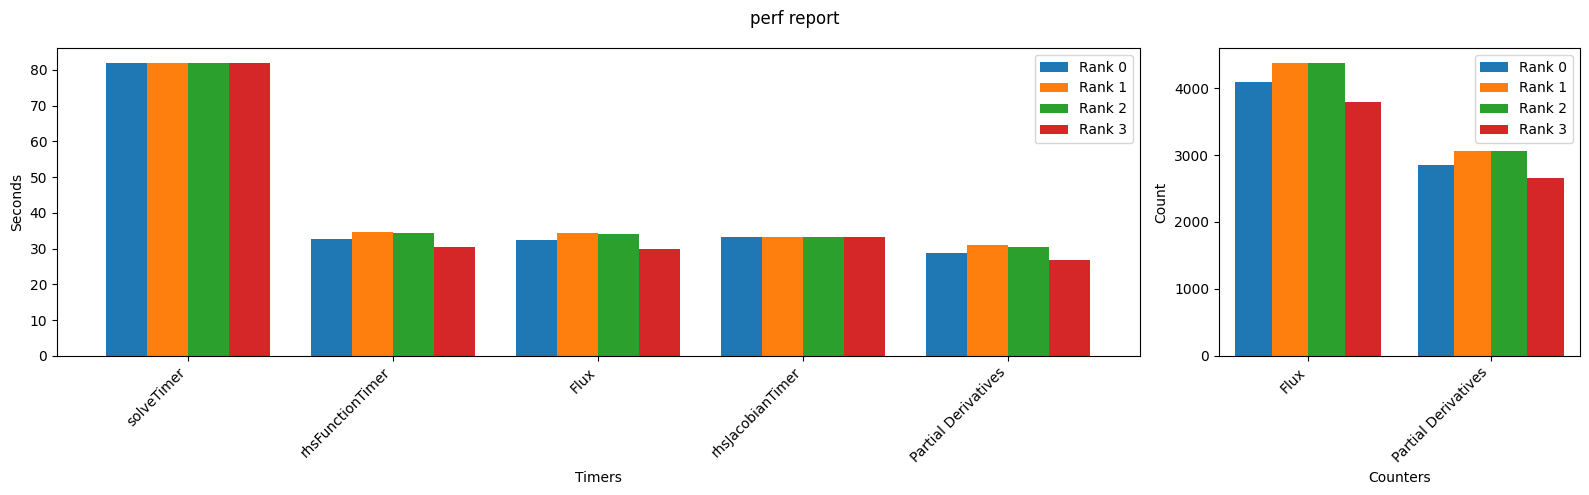

In [7]:

if rootDir2:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), gridspec_kw={'width_ratios': [3, 1]})
    fig.suptitle(baseName or "perf report")
    data2 = getDataFromFiles(rootDir2, baseName=baseName)

    plotLocal(axes[0][0], axes[0][1], data1)
    plotLocal(axes[1][0], axes[1][1], data2)

    print("Average solveTimer (run1):", getAverage('solveTimer', data1))
    print("Average solveTimer (run2):", getAverage('solveTimer', data2))
    print("Average rhsJacobianTimer (run1):", getAverage('rhsJacobianTimer', data1))
    print("Average rhsJacobianTimer (run2):", getAverage('rhsJacobianTimer', data2))
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [3, 1]})
    fig.suptitle(baseName or "perf report")
    plotAll(axes[0], axes[1], data1)
    print("Average rhsJacobianTimer:", getAverage('rhsJacobianTimer', data1))

plt.tight_layout()
plt.show()
